In [26]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


Прочитаем все данные и выведем первые строки для наглядности


In [10]:
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')
submission = pd.read_csv('/kaggle/input/competitions/titanic/gender_submission.csv')

In [11]:
train.head()
#test.head()
#submission.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
train.shape
#test.shape

(891, 12)

Теперь необходимо подготовить наши данные для обучения модели. Начинаем с разбиения тренировочных данных на две группы: 
* тренировочная. На этих данных наша модель будет тренироваться
* и проверочные. Это данные, которые будут использоваться для оценивания точности предсказания нашей модели

Обычно 80% - это тренировочная часть и 20% - проверочная

In [13]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=['PassengerId', 'Survived'])
y = train['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1)

Теперь необходимо разобраться с пропавшими данными по каким-то причинам. Сначала необходимо узнать какие столбы вообще имеют неизвестные значения и сколько их.

In [14]:
X_train.isna().sum() #вывод: все столбцы и сколько в них пропускох (считая ноль)
X_NaN = X_train.isna().sum()[X_train.isna().sum() > 0] #ноль не интересен, поэтому убираем его
X_NaN.head()

Age         144
Cabin       547
Embarked      2
dtype: int64

Воспользуемся методами избавления от неизвестных данных.
**Важно!** Необходимо знать ответ на вопрос: *Это значение отсутствует, потому что оно не было записано или потому что оно не существует?*

Если значение отсутствует, потому что оно не существует (например, рост старшего ребенка у кого-то, у кого нет детей), то нет смысла пытаться угадать, что это может быть. Эти значения, вероятно, действительно необходимо сохранить как NaN. 

Иначе, если значение отсутствует из-за того, что оно не было записано, можно попытаться угадать, что это могло быть

**Первый способ.** Удаление всех столбцов в которых есть значение NaN. Или удалить все строки со значением NaN. У этого способа есть огромный минус в виде потери значимого количества данных. В нашем случае либо потерей 3 столбцов из 12, либо потерей минимум 547 строк из 891, что очень значительно и в первом и во втором случае

In [15]:
X_train_clean_col = X_train.dropna(axis=1)
#X_train_clean_col = X_train.drop(columns=X_NaN.index) - работает аналогично 

X_train_clean_row = X_train.dropna(axis=0)

In [16]:
X_train_clean_col.head()

,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare
301,3,"McCoy, Mr. Bernard",male,2,0,367226,23.2500
309,1,"Francatelli, Miss. Laura Mabel",female,0,0,PC 17485,56.9292
516,2,"Lemore, Mrs. (Amelia Milley)",female,0,0,C.A. 34260,10.5000
120,2,"Hickman, Mr. Stanley George",male,2,0,S.O.C. 14879,73.5000
570,2,"Harris, Mr. George",male,0,0,S.W./PP 752,10.5000


In [17]:
X_train_clean_row.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
309,1,"Francatelli, Miss. Laura Mabel",female,30.0,0,0,PC 17485,56.9292,E36,C
516,2,"Lemore, Mrs. (Amelia Milley)",female,34.0,0,0,C.A. 34260,10.5000,F33,S
730,1,"Allen, Miss. Elisabeth Walton",female,29.0,0,0,24160,211.3375,B5,S
311,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
194,1,"Brown, Mrs. James Joseph (Margaret Tobin)",female,44.0,0,0,PC 17610,27.7208,B4,C


**Второй способ.** Найти и заполнить все ячейки каким-то константным значением. Здесь очень важно всегда проверять что изменяемые данные - это наш тренировочный вариант, чтобы не произошло утечки данных (например, если использовать этот способ к dataframe X и заменять все числовые значения на средние, то произойдет утечка данных при обучении модели на X_train).

In [18]:
X_train_replace = X_train.copy()

# Находим числовые столбцы и заполняем их средним
num_cols = X_train.select_dtypes(include='number').columns
X_train_replace[num_cols] = X_train[num_cols].fillna(X_train[num_cols].mean())

# Находим текстовые столбцы и заполняем их строкой 'unknown'
cat_cols = X_train.select_dtypes(include='object').columns
X_train_replace[cat_cols] = X_train[cat_cols].fillna('unknown')

In [19]:
X_train_replace.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
301,3,"McCoy, Mr. Bernard",male,30.166232,2,0,367226,23.2500,unknown,Q
309,1,"Francatelli, Miss. Laura Mabel",female,30.000000,0,0,PC 17485,56.9292,E36,C
516,2,"Lemore, Mrs. (Amelia Milley)",female,34.000000,0,0,C.A. 34260,10.5000,F33,S
120,2,"Hickman, Mr. Stanley George",male,21.000000,2,0,S.O.C. 14879,73.5000,unknown,S
570,2,"Harris, Mr. George",male,62.000000,0,0,S.W./PP 752,10.5000,unknown,S


**Третий способ.** Последним вариантом является добавление нового столбца-индекса неизвестности. То есть это просто столбец который показывает, пропущен ли в каком-то из столбцов значение.

In [20]:
X_train_add_ind = X_train.copy()
for col in X_NaN.index:
    # Создаем новый бинарный столбец-индикатор (1 - был пропуск, 0 - данные на месте)
    X_train_add_ind[f'{col}_isNaN'] = X_train[col].isna().astype(int)

In [21]:
X_train_add_ind.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_isNaN,Cabin_isNaN,Embarked_isNaN
301,3,"McCoy, Mr. Bernard",male,NaN,2,0,367226,23.2500,NaN,Q,1,1,0
309,1,"Francatelli, Miss. Laura Mabel",female,30.0,0,0,PC 17485,56.9292,E36,C,0,0,0
516,2,"Lemore, Mrs. (Amelia Milley)",female,34.0,0,0,C.A. 34260,10.5000,F33,S,0,0,0
120,2,"Hickman, Mr. Stanley George",male,21.0,2,0,S.O.C. 14879,73.5000,NaN,S,0,1,0
570,2,"Harris, Mr. George",male,62.0,0,0,S.W./PP 752,10.5000,NaN,S,0,1,0


Теперь все те же операции необходимо проделать и для X_val ведь модель у нас не будет понимать что делать с данными NaN

In [22]:
# 1 способ 
X_val_clean_col = X_val.dropna(axis=1)
X_val_clean_row = X_val.dropna(axis=0)

# 2 способ
X_val_replace = X_val.copy()
X_val_replace[num_cols] = X_val[num_cols].fillna(X_val[num_cols].mean())
X_val_replace[cat_cols] = X_val[cat_cols].fillna('unknown')

# 3 способ
X_val_add_ind = X_val.copy()
for col in X_NaN.index:
    # Создаем новый бинарный столбец-индикатор (1 - был пропуск, 0 - данные на месте)
    X_val_add_ind[f'{col}_isNaN'] = X_val[col].isna().astype(int)

После того как все неизвестные данные были обработанны каким-то из пердшествующих методов, необходимо дальше подготовить данные для модели, а именно подготовить числовые столбцы и категориальные для дальнейшей работы.


Сначала обработаем все числовые столбцы. Всего можно выделить 9 видов работы с числовыми признаками:
1. Анализ распределения.
2. Обработка выбросов.
3. Трасформация формы.
4. Масштабирование.
5. Мультиколлинеарность.
6. Снижение рамерности.
7. Отбор признаков
8. Бинаризация или дискретизация
9. Feature Engineering



**Шаг первый.** В первую очередь проанализируем все распределения:

Для этого будем использовать два параметра Skewness - коэффицент ассиметрии, то есть то на сколько данные склоняются в какую-то сторону. Если это значение будет >1 значит нам надо будет что-то делать с этими данными на последующих шагах. Вторым нашим параметром будет Kurtosis - число, которое показывает "остроту" пика и толщину хвостов распределения по сравнению с нормальными. Это коэффициент эксцесс. Если он высокий, то в данных есть очень резкий, высокий пик в одном месте (например, почти все значения сосредоточены вокруг одного числа) и при этом могут юыть очень длинные редкие хвосты с выбросами.

Для простоты будем использовать только X_train_replace, так как обычно такой подход приносить более хороший результат и не сильно загржает таблицу новыми данными. Первый способ нам сильно сократил строки. Третий способ для последующих обработок прийдется немного переделать и заменить все NaN данные на какую-то константу. Алгоритмы не умеют работать с NaN данными, поэтому у нас будет таблица второго способа с дополнительными столбцами-индикаторами. И обрабатывать столбцы-индикаторы мы не будем, поэтому для удобства третий способ так же отложим.

Столбец: Pclass
  -> Skewness (асимметрия): -0.61
  -> Kurtosis (эксцесс):    -1.30
----------------------------------------
Столбец: Age
  -> Skewness (асимметрия): 0.43
  -> Kurtosis (эксцесс):    0.93
----------------------------------------
Столбец: SibSp
  -> Skewness (асимметрия): 3.72
  -> Kurtosis (эксцесс):    19.30
----------------------------------------
Столбец: Parch
  -> Skewness (асимметрия): 2.71
  -> Kurtosis (эксцесс):    9.73
----------------------------------------
Столбец: Fare
  -> Skewness (асимметрия): 3.99
  -> Kurtosis (эксцесс):    23.62
----------------------------------------


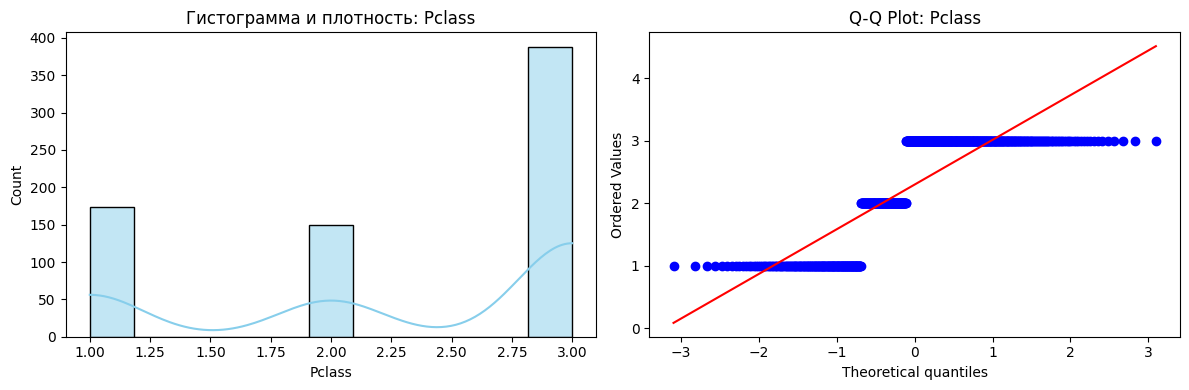

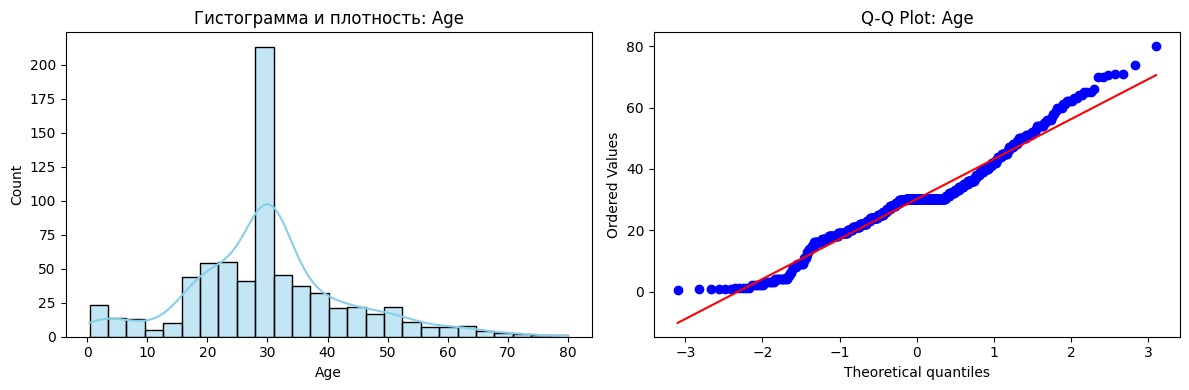

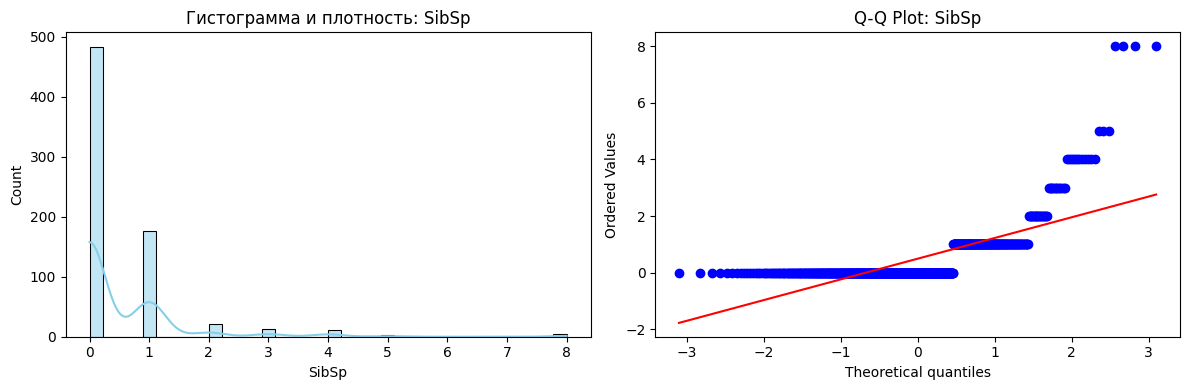

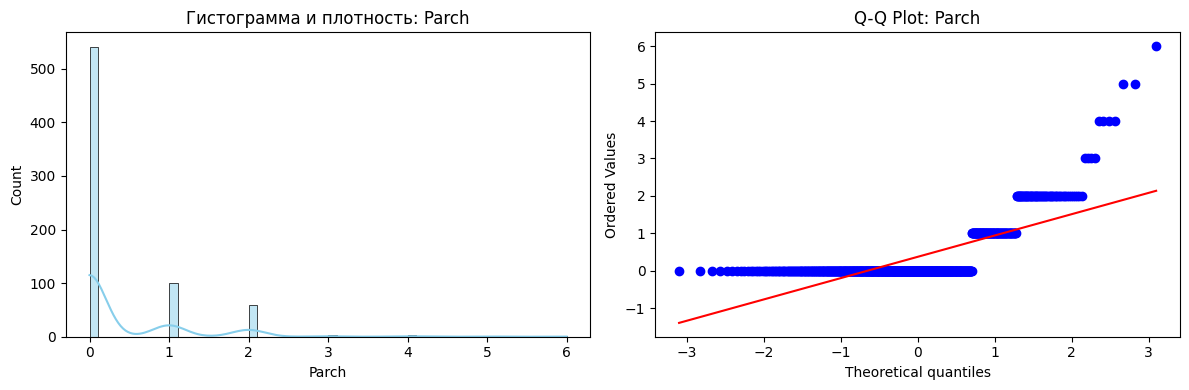

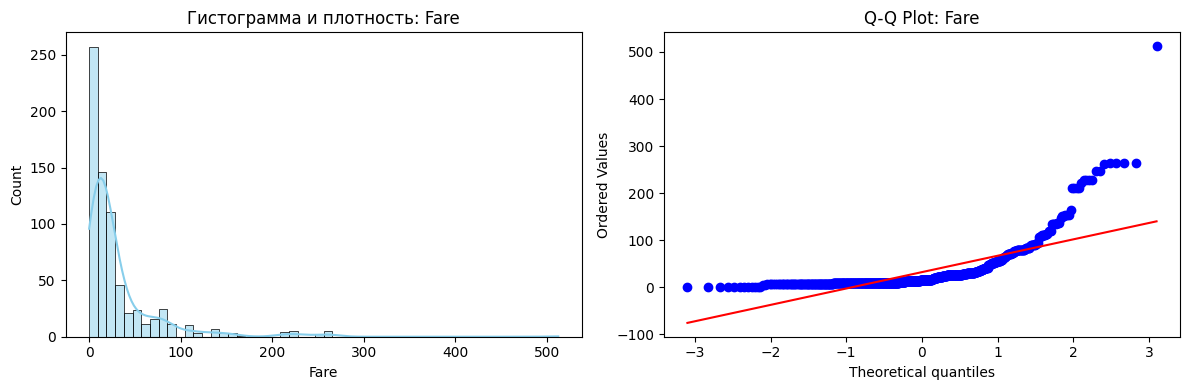

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Cчитаем Skewness и Kurtosis для каждого столбца
for col in num_cols:
    skew_val = X_train_replace[col].skew()
    kurt_val = X_train_replace[col].kurt()
    
    print(f"Столбец: {col}")
    print(f"  -> Skewness (асимметрия): {skew_val:.2f}")
    print(f"  -> Kurtosis (эксцесс):    {kurt_val:.2f}")
    print("-" * 40)

# Визуальный анализ: строим гистограмму и Q-Q Plot для каждой числовой колонки
for col in num_cols:
    # Позволяет вывести два графика в одну строчку
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Слева: Гистограмма распределения + линия плотности (Density plot)
    sns.histplot(X_train_replace[col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Гистограмма и плотность: {col}')
    
    # Справа: График Q-Q Plot
    stats.probplot(X_train_replace[col], dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q Plot: {col}')
    
    plt.tight_layout()
    plt.show()

Гистограмма нам позволяет увидеть вокруг каких значений группируются данные и насколько плавно они распределены. Идеальные данные будут похожи на симметричную горку. Сразу видно что на последних трех графиках все данные сконцентрированны в начале: виден резкий пик и дальнейший тянущийся хвост. Это так же понятно по огромному значению kurtisis, но на графиках наглядно видно какие именно пики существуют. 

Второй график Q-Q Plot акентирует внимание на краях, ведь гистограмма часто их размывает. Если выбросов очень малое количество гистограмма их вообще не покажет. Поэтому второй график оценивает каество хвостов. Он берет квантильи реальных данных (синие точки) и сравнивает их с квантилями идеального нормального распределения (обозначено красной прямой линией). Поэтому если данные идельны, то они будут лежать строго на красной линии. Тога по графикам видно что сильные выбросы есть только у последних трех столбцов (правый хвост резко взлетает вверх, аналогично было бы если левые точки резко падали вниз)

**Шаг второй.** Мы примерно поняли какие столбцы имеют проблему. Отложим пока проблемные гистограмы и вторым шагом исправим все выбросы. Мы уже поняли что столбцы SibSp, Parch и Fare имеют выбросы. На данном шаге нам необходимо подлечить эти числовые столбцы.

Тут возникает сложность в выборе алгоритма. Существует 6 самых распространенных методов. Разберем подробно каждый способ. 

**Первый способ.** Рассмотрим самый распространенный способ работы с выбросами - IQR. Метод межквартильного размаха находит центральные 50% данных от 25-го до 75-го прецентиля. Размах между ними - это $IQR = Q_3 - Q_1$. Границы нормы: $[Q_1 - 1.5 * IQR, Q_3 + 1.5 * IQR]$. Значения же за границами не удаляются, а прижимаются к ним через метод .clip(). Этот метод устойчив к форме распределения (не ребует нормальности), поэтому он очень удобный и самый распространенный.

In [49]:
X_train_replace_iqr = X_train_replace.copy()
X_val_replace_iqr = X_val_replace.copy()

for col in X_train_replace.select_dtypes(include='number').columns:
    q25, q75 = X_train_replace[col].quantile(0.25), X_train_replace[col].quantile(0.75)
    iqr = q75 - q25
    lower, upper = q25 - 1.5 * iqr, q75 + 1.5 * iqr
    
    X_train_replace_iqr[col] = X_train_replace_iqr[col].clip(lower=lower, upper=upper)
    X_val_replace_iqr[col] = X_val_replace_iqr[col].clip(lower=lower, upper=upper)

**Второй способ.** Вторым способом является метод трех сигм. Он работает строго по правилу нормального распределения, поэтому очень часто его невозможно применить. В пределах трех стандартных отклонений ($\sigma$) от среднего арифметического ($\mu$) лежит 99.7% всех данных. Границы нормы: $[\mu - 3\sigma, \; \mu + 3\sigma]$. Как уже и было сказано такой метод подходит только для признаков, которые на первом шаге показали форму симметричного колокола (например, Age). Если же применить его к сильно скошенным тратам, он посчитает неадекватные границы (нижняя граница уйдет в минус). 

In [37]:
X_train_replace_3sig = X_train_replace.copy()
X_val_replace_3sig = X_val_replace.copy()

for col in X_train_replace.select_dtypes(include='number').columns:
    mu = X_train_replace[col].mean()
    sigma = X_train_replace[col].std()
    lower, upper = mu - 3 * sigma, mu + 3 * sigma
    
    X_train_replace_3sig[col] = X_train_replace_3sig[col].clip(lower=lower, upper=upper)
    X_val_replace_3sig[col] = X_val_replace_3sig[col].clip(lower=lower, upper=upper)

**Третий способ.** Третий способ, наверное, самый простой и понятный - это удаление по жестким прецентилям (Percentile Trimming). Мы жестко срезаем фиксированный процент самых экстремальных данных. Этот метод отлично подходит, когда нужно гарантированно избавиться от шума на краях, не привязываясь к средним или медианам. 

In [36]:
X_train_replace_perc = X_train_replace.copy()
X_val_replace_perc = X_val.copy()

for col in X_train_replace.select_dtypes(include='number').columns:
    lower = X_train_replace[col].quantile(0.01)
    upper = X_train_replace[col].quantile(0.99)
    
    X_train_replace_perc[col] = X_train_replace_perc[col].clip(lower=lower, upper=upper)
    X_val_replace_perc[col] = X_val_replace_perc[col].clip(lower=lower, upper=upper)

Если до этого мы работали строго со столбцами, то четвертый и пятый способы анализируют уже всю таблицу. Они находят строки-аномалии по комбинации признаков и выдают метки 1 - нормальный обьект или -1 - выброс. **Важно,** что удалять строки по этим меткам можно только в тренировочных данных, в валидации удалять строки нельзя, чтобы не нарушить тестовую структуру ответов.

Эти два метода лучше всего использовать на уже немного линейно переработанных данных алгоритмами, описанными выше. Многомерные алгоритмы ищют нестыковку не в одном столбце (человек 200 лет), а в связи нескольких столбцов (например, пятилетний ребенок потратил несколько миллиардов долларов). Поэтому, чтобы не заставлять алгоритмы тратить большое количество времени на отделение этих столбцовых выбросов, предвартиельно их обрабатывают одномерными методами.

**Четвертый способ.** Изоляционный лес (Isolation Forest). Этот алгоритм строит ансамбль случайных деревьев и пытается изолировать каждый обьект случайными сплитами. Его логика определения выброса заключается в том, что если точка стоит в куче с другими, дереву нужно много раз ветвиться, чтобы до нее добраться. Если точка одинокая и странная, то она изолируется за 2-3 шага.

In [41]:
from sklearn.ensemble import IsolationForest

# contamination=0.05 означает, что мы ожидаем около 5% выбросов в данных
iso_forest = IsolationForest(contamination=0.05, random_state=1) 

# Находим аномалии
train_labels = iso_forest.fit_predict(X_train_replace_iqr.select_dtypes(include='number'))

# Удаляем аномальные СТРОКИ только из тренировочного набора
X_train_replace_no_outliers = X_train_replace_iqr[train_labels == 1]
y_train_no_outliers = y_train[train_labels == 1] # не забываем отфильтровать таргет!

**Пятый способ.** Следующим методом является Local Outlier Factor (LOF). Алгоритм оценивает локальную плотность обьектов. Он берет точку, смотрит на ее k-ближайших соседей и сравнивает их плотности. Если точка лежит в разреженном пространстве, а все ее соседи - в плотном кластере, значит, эта точка - выброс.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# Обучаем LOF. Параметр novelty=True обязателен, чтобы метод мог предсказывать на новых данных
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, novelty=True)
lof.fit(X_train_replace_iqr.select_dtypes(include='number'))

train_labels_lof = lof.predict(X_train_replace_iqr.select_dtypes(include='number'))

X_train_replace_lof_clean = X_train_iqr[train_labels_lof == 1]
y_train_lof_clean = y_train[train_labels_lof == 1]

**Шестой способ.** Последним способом является лечение скейлингом. То есть мы пытаемся избавиться от выбросов не их удалением, а каким-то образом масштабированием. Для этого на шаге четыре нам понадобиться применять RobustScale, который центрирует данные по медиане и масштабирует их по IQR, благодаря чему выбросы сжимаются математически и не сдвигают веса линейных моделей. Подробнее данные метод мы разберем уже на четвертом шаге.

Дальше два кода, которые показывают как изменились наши данные после обработки выбросов для одномерных и многомерных методов соответственно.

In [53]:
# Выбираем для примера один самый "выбросный" столбец (например, траты или возраст)
test_col = 'Fare'

# Объединяем статистики в одну красивую табличку для сравнения
compare_df = pd.DataFrame({
    'ДО обработки': X_train_replace[test_col].describe(),
    'ПОСЛЕ IQR': X_train_replace_iqr[test_col].describe()
})

print(compare_df)

       ДО обработки   ПОСЛЕ IQR
count    712.000000  712.000000
mean      31.951567   23.995536
std       46.313942   20.382067
min        0.000000    0.000000
25%        7.895800    7.895800
50%       14.458300   14.458300
75%       30.695800   30.695800
max      512.329200   64.895800


In [55]:
# 1. Проверяем изменение размера таблицы
print(f"Строк ДО очистки леса:    {X_train_replace_iqr.shape[0]}")
print(f"Строк ПОСЛЕ очистки леса: {X_train_replace_no_outliers.shape[0]}")
print(f"Удалено аномальных строк: {X_train_replace_iqr.shape[0] - X_train_replace_no_outliers.shape[0]}")
print("-" * 50)

# 2. Смотрим на сами выбросы, которые поймал Isolation Forest
# (берём строки, где метка была равна -1)
outliers = X_train_replace_iqr[train_labels == -1]

print("Пример аномальных пассажиров, которых нашел алгоритм:")
outliers.head(5) # Выведет топ-5 самых странных строк датасета

Строк ДО очистки леса:    712
Строк ПОСЛЕ очистки леса: 712
Удалено аномальных строк: 0
--------------------------------------------------
Пример аномальных пассажиров, которых нашел алгоритм:


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


**Шаг третий.** Теперь вернемся к графикам из шага 1 и обработаем данные из проблемных гистограм. Этот шаг называется *трансформация формы распределения*. Этот шаг необходим для нормализации данных, чтобы распределения стало более похоже выглядеть на колокол и данные стали более сгруппированными.

Тут так же есть несколько различных вариантов трансформации, разберем их на наших проблемных столбцах. Все будем писать на примере работы первого алгоритва из шага два IQR.

**1.** Наверное, самый распространенный и удобное из всех способ - это логарифмирование. Можно использовать разныел логарифмы $log2,\ log10,\ log$. Но самый распространненый и частый для правого хвоста - это $log1p$. Используется чаще всего, если скос сильный skewness > 1.5, и в данных есть нули. Такой метод сжимает гигантские значения и растягивает мелкие. Это превратит скошенный график в более симметричный колокол.

In [58]:
import numpy as np

X_train_log = X_train_replace_iqr.copy()
X_val_log = X_val_replace_iqr.copy()

# Находим оригинальные числовые столбцы
#num_cols = [col for col in X_train_log.select_dtypes(include='number').columns]

for col in num_cols:
    # Проверяем критерий скошенности строго по трейну
    if X_train_replace_iqr[col].skew() > 1.0:
        X_train_log[col] = np.log1p(X_train_log[col])
        X_val_log[col] = np.log1p(X_val_log[col])

**2.** Следующий частый способ - это степенные. Так же можно использовать много разных вариантов $sqrt,\ cbrt,\ x^2,\ x^3$. Обычно используют только квадратный корень. Так как корень сжимает данные мягче логарифма, то этот метод используется, если скос 1.0 < skewness < 1.5. Логарифм может оказаться слишком радикальным средством, которое перекосит данные уже в противоположную левую сторону.

In [59]:
X_train_sqrt = X_train_replace_iqr.copy()
X_val_sqrt = X_val_replace_iqr.copy()

for col in num_cols:
    if X_train_replace_iqr[col].skew() > 1.0:
        X_train_sqrt[col] = np.sqrt(X_train_sqrt[col])
        X_val_sqrt[col] = np.sqrt(X_val_sqrt[col])

**3.** Третьим способом рассмотрим обратные преобразования, их так же много видов, но обычно используется или $1/x$, или $1/(x+1)$ - для избавления от нулей. 

Этот вариант сомнительный ведь он переварачивает маленькие значения и делает их огромными, а большие - наоборот. Способ идеально подходит, когда физический смысл признака логичнее инвертироватью Например, если есть *время на прохождение 1 км*, то для медленных машин этот признак превратится в *скорость*, распределение которой обычно гораздо более симметрично.

In [60]:
X_train_inv = X_train_replace_iqr.copy()
X_val_inv = X_val_replace_iqr.copy()

for col in num_cols:
    if X_train_replace_iqr[col].skew() > 1.0:
        # Добавляем +1 для защиты от деления на ноль
        X_train_inv[col] = 1.0 / (X_train_inv[col] + 1.0)
        X_val_inv[col] = 1.0 / (X_val_inv[col] + 1.0)

**4.** Теперь переходим к более сложным трансформациям, которые одной функцией записать не получится. Рассмотрим сначала автоматическое преобразование Бокса-Кокса. Его все еще можно записать формулой: $$y = \begin{cases} \frac{x^\lambda - 1}{\lambda}, & \text{если } \lambda \neq 0 \\ \ln(x), & \text{если } \lambda = 0 \end{cases}$$

Алгоритм будет переебирать параметр $\lambda$ и искать такое его значение, которое сделает итоговое распределение максимольно близким к идеальному нормальному распределению. Плюс заключается в том что он может превратить данные в корень, логарифм, возвести в степень или инвертировать. **Важно!** Главное ограничение, что работает строго для чисел > 0.

In [61]:
from sklearn.preprocessing import PowerTransformer

X_train_bc = X_train_replace_iqr.copy()
X_val_bc = X_val_replace_iqr.copy()

# Отбираем только те колонки, где skew > 1 и все значения строго положительные
bc_cols = [col for col in num_cols if X_train_replace_iqr[col].skew() > 1.0 and (X_train_replace_iqr[col] > 0).all()]

if bc_cols:
    pt_bc = PowerTransformer(method='box-cox')
    # Обучаемpt строго на трейне, трансформируем оба!
    X_train_bc[bc_cols] = pt_bc.fit_transform(X_train_bc[bc_cols])
    X_val_bc[bc_cols] = pt_bc.transform(X_val_bc[bc_cols])

**5.** Следуюзим рассмротим автоматическое преобразование Йео-Джонсона. Это модифицированная версия предыдущего метода Бокса-Кокса, созданное для того, чтобы убрать главное ограничение. Поэтому математическая формула очень сложная, но смысл работы остается такой же: подобрать параметр $\lambda$ для выравнивания распределения. Это универсальный и умный степенной скейлер, который сам подбирает функцию вырванивания и умеет работать с нулями и минусами. Поэтому его чаще выбирают вместо алгоритма Бокса-Кокса.

In [67]:
from sklearn.preprocessing import PowerTransformer

X_train_yj = X_train_replace_iqr.copy()
X_val_yj = X_val_replace_iqr.copy()

yj_cols = [col for col in num_cols if X_train_replace_iqr[col].skew() > 1.0]

if yj_cols:
    pt_yj = PowerTransformer(method='yeo-johnson')
    X_train_yj[yj_cols] = pt_yj.fit_transform(X_train_yj[yj_cols])
    X_val_yj[yj_cols] = pt_yj.transform(X_val_yj[yj_cols])

**6.** Последним рассмотрим самый мощный метод квантильное выравнивание (Quantile Transformation). Он полностью игнорирует изначальную математическую формулу признака. Он берет ранги данных и принудительно разазывает их по теоретическим квантилям нормального распределения. Благодаря этому оно способно превратить распределение любого вида в идеальную, прямую линию на Q-Q Plot и безупречный колокол нормального распределения.

За такие идеальные возможности приходится платить. Из-за сврех-идеального распределения размывается пропорции и относительные расстрояние. Например, пассажир А потратил 10 и пассажир Б потратил 10 000. После логарифма расстояния уменьшатся, но модель всё равно будет четко понимать: Б потратил намного больше, чем А.

QuantileTransformer же переводит данные в ранги (порядковые номера). Ему важен только порядок объектов. Если между Б и А в датасете никто больше ничего не тратил, то Б и В на распределении окажутся совсем рядом. Абсолютная разница в деньгах (9 990) просто сотрется. Модель потеряет информацию о масштабе экономического превосходства клиента Б.

In [69]:
from sklearn.preprocessing import QuantileTransformer

X_train_qt = X_train_replace_iqr.copy()
X_val_qt = X_val_replace_iqr.copy()

qt_cols = [col for col in num_cols if X_train_replace_iqr[col].skew() > 1.0]

if qt_cols:
    n_quant = min(500, X_train_replace_iqr.shape[0])

    # output_distribution='normal' принудительно заставляет ранги лечь на нормальную прямую
    qt = QuantileTransformer(n_quantiles=n_quant, output_distribution='normal', random_state=42)
    X_train_qt[qt_cols] = qt.fit_transform(X_train_qt[qt_cols])
    X_val_qt[qt_cols] = qt.transform(X_val_qt[qt_cols])
    

Результат посмотрим на прмиере $log1p$. Можно поменять на любую из таблиц выше.

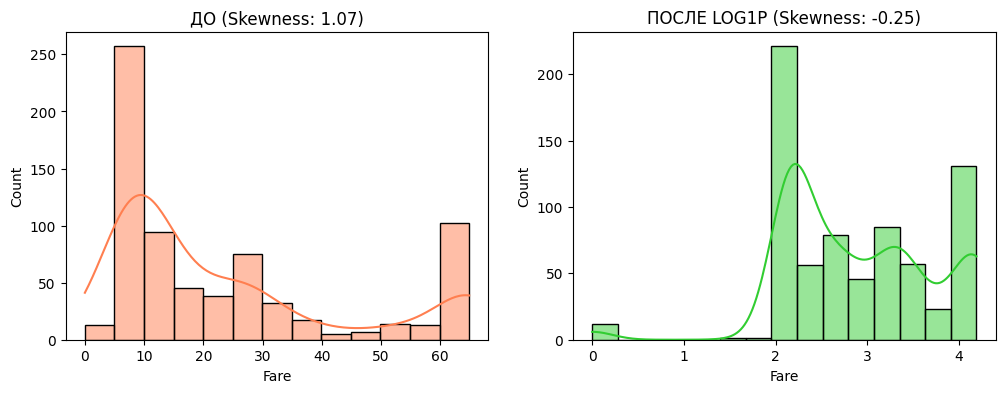

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = 'Fare'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X_train_replace_iqr[target_col], kde=True, ax=axes[0], color='coral')
axes[0].set_title(f'ДО (Skewness: {X_train_replace_iqr[target_col].skew():.2f})')

sns.histplot(X_train_log[target_col], kde=True, ax=axes[1], color='limegreen')
axes[1].set_title(f'ПОСЛЕ LOG1P (Skewness: {X_train_log[target_col].skew():.2f})')
plt.show()

Стало заметно лучше и график стал более похож на колокол.

**Шаг четвертый.** Масштрабирование признаков. Этот этап технически необходим большинству моделей. Без масштабирования признаки с большим масштабом будет полностью доминировать над признаком с маленьких масштабом.

Разберем это на примере: Если первый числовой столбец принимает значения от 0 до 10, а второй имеет минимальное зачение больше 1 000 000, то второй столбец надо будет преобразовывать. Ведь в линейных моделях веса первого столбца будут во много раз больше, чем веса второго столбца. Это создаст ненужный шум, который ухудшит точность нашей модели. Для нелинейных моделей, хоть такие данные и меньше влияют на точность, но все равно создают шум, который можно спокойно устранить при желании.

Рассмотрим самые распространненые типы масштабирования и напишем код на пример $log1p$.

**Первый тип.** Стандартизация (StandardScaler). Математическая формула:$$z = \frac{x - \mu}{\sigma}$$где $\mu$ - среднее арифметическое, а $\sigma$ - стандартное отклонение. 

Этот алгоритм сдвигает распределение так, что среднее значение признака становится равным 0, а диспресия и стандартное отклонение - 1. К сожалению, крайне чувствителен к выбросам. Если в данных остался огромный пик, он раздует $\sigma$, и все нормальные значения сожмутся в очень маленький интервал около нуля.

In [74]:
from sklearn.preprocessing import StandardScaler

X_train_scaled_st = X_train_log.copy()
X_val_scaled_st = X_val_log.copy()


scaler_st = StandardScaler()
# fit_transform делаем строго на ТРЕЙНЕ, на валидации только transform!
X_train_scaled_st[num_cols] = scaler_st.fit_transform(X_train_scaled_st[num_cols])
X_val_scaled_st[num_cols] = scaler_st.transform(X_val_scaled_st[num_cols])

**Второй тип.** Мин-Макс нормализация (MinMaxScaler). Математическая формула:$$x_{\text{scaled}} = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}$$

Алгоритм жестко сжимает все данные в фиксированный диапазон, от -1 до 1. Аналогично предыдущему алгоритму очень чувствителен к выбросам, поэтому обязательно необходимо что-то с ними сделать.

In [78]:
from sklearn.preprocessing import MinMaxScaler

X_train_scaled_mm = X_train_log.copy()
X_val_scaled_mm = X_val_log.copy()

scaler_mm = MinMaxScaler()
X_train_scaled_mm[num_cols] = scaler_mm.fit_transform(X_train_scaled_mm[num_cols])
X_val_scaled_mm[num_cols] = scaler_mm.transform(X_val_scaled_mm[num_cols])

**Трерий тип.** RobustScaler. Этот способ, о котором было написано в шаге 2. Математическая формула: $$x_{\text{scaled}} = \frac{x - \text{median}}{Q_3 - Q_1}$$где $Q_1$ и $Q_3$ — это 25-й и 75-й перцентили, а их разница ($Q_3 - Q_1$) — это уже знакомый нам межквартильный размах $IQR$. 

Ключевой плюс в том что он лечит выбросы, вместо средних значений он использует медиану (центр), а вместо стандартного отклонения - IQR (ширину основной массы данных).  Поскольку перцентили не смотр на экстремальные значения, масштаб рассчитывается только по нормальной массе данных. Поэтому этот метод обычно используется когда на шаге 2 выбросы решили умышленно не обрезать через .clip()

In [79]:
from sklearn.preprocessing import RobustScaler

# Берем данные ДО обрезки выбросов (например, сразу после заполнения пропусков с индикаторами)
X_train_scaled_rob = X_train_add_ind.copy() 
X_val_scaled_rob = X_val_add_ind.copy()

scaler_rob = RobustScaler()
X_train_scaled_rob[num_cols] = scaler_rob.fit_transform(X_train_scaled_rob[num_cols])
X_val_scaled_rob[num_cols] = scaler_rob.transform(X_val_scaled_rob[num_cols])

Есть еще два способа, но они были подробно расписаны на предыдущем шаге. Напишем только то, как они связаны с масштабированием: 
* **QuantileTransformer:** Этот алгоритм переводит данные в ранги и принудительно раскладывает по нормальному распределению. Поэтому этот алгоритм одновременно решает задачу и зименения формы, и изменения масштаба.
* **PowerTransformer (Yeo-Johnson / Box-Cox):** Эти два алгоритма находят оптимальную степень для выпрямления распределения, а после этого автоматически применяет стандартизацию (StandardScaler), приводя среднее к 0 и дисперсию к 1.


Поэтому тут не будем зацикливаться на этих алгоритмах и покажем просто то, как нашу таблицу изменили алгоритмы масштабирования. Написано на примере StandardScaler.

In [80]:
import pandas as pd

test_col = 'Fare' 

# Собираем описательные статистики в одну таблицу для сравнения
compare_scaling = pd.DataFrame({
    'ДО масштабирования': X_train_log[test_col].describe(),    # Таблица из Шага 3
    'ПОСЛЕ StandardScaler': X_train_scaled_st[test_col].describe() # Итоговая таблица из Шага 4
})

# Настраиваем отображение чисел
pd.set_option('display.float_format', lambda x: '%.6f' % x)

print("Сравнение статистик для столбца:", test_col)
print(compare_scaling)

Сравнение статистик для столбца: Fare
       ДО масштабирования  ПОСЛЕ StandardScaler
count          712.000000            712.000000
mean             2.892539             -0.000000
std              0.835277              1.000703
min              0.000000             -3.465405
25%              2.185579             -0.846973
50%              2.738146             -0.184971
75%              3.456184              0.675275
max              4.188075              1.552116


Ключевое что надо заметить - это изменение mean и std. Они стали 0  и 1 соответсвенно.

**Шаг пятый.** Теперь необходимо избавиться от мультиколлинеарности. Если два или более признаков очень сильно связаны друг с другом, то веса этих признаков при обучении модели улетают в бесконечность и знаки меняются на случайные, поэтому для линейных моделей мультиколлинеарные признаки смертельны. Для деревьев и бустрингов - это практически безвредно, поэтому для таких моделей пункт можно пропускать.

Рассмотрим **первый способ** матрицу корреляций (Пирсона). коэффициент корреляции Пирсона $r_{xy}$ между каждой парой числовых признаков. Он меняется от $-1$ до 1. На практике, если $|r_{xy}| > 0.8$ или $> 0.9$, один из этих двух признаков скорее всего надо удалять.

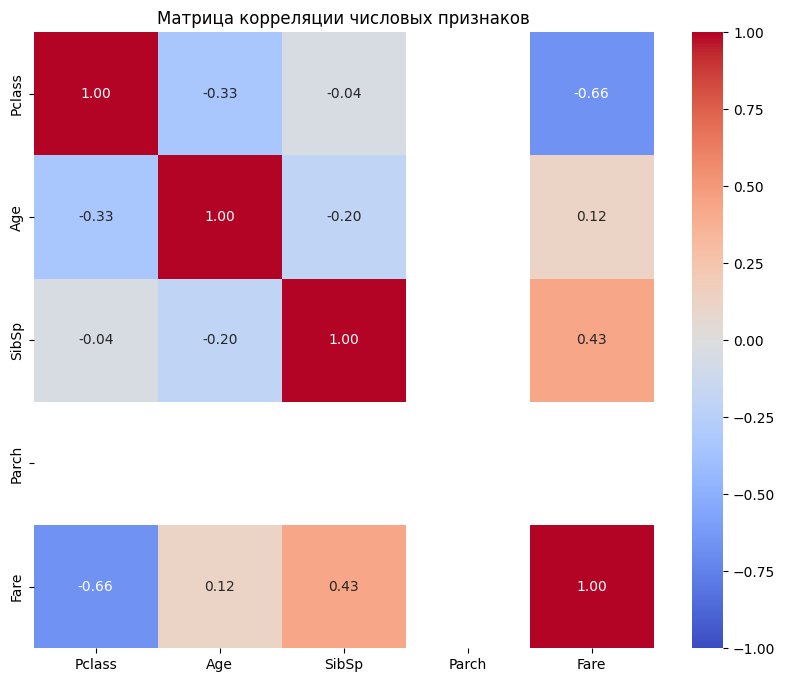

Столбцы, которые рекомендуется удалить из-за высокой корреляции: []


In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Строим матрицу корреляций Пирсона
corr_matrix = X_train_scaled_st[num_cols].corr()

# 2. Красиво её визуализируем через тепловую карту (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Матрица корреляции числовых признаков')
plt.show()

# 3. Автоматический поиск и составление списка сильно связанных признаков (порог > 0.8)
threshold = 0.8
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for col in upper_tri.columns if any(upper_tri[col].abs() > threshold)]

print(f"Столбцы, которые рекомендуется удалить из-за высокой корреляции: {to_drop}")

**Метод два.** Рассмотрим другой способ - фактор инфляции дисперсии (Variance Inflation Factor VIF). Матрица Пирсона ловит только парную корреляцию, поэтому VIF решает проблему, если признак сильно коррелирует с суммой других признаков, но недостаточно сильно с ними поотдельности. Формула VIF:$$VIF_i = \frac{1}{1 - R_i^2}$$где $R_i^2$ — коэффициент детерминации этой внутренней модели.

Если VIF = 1 корреляции нет вообще, если >5 то есть умеренная мультиколлинеарность, а если VIF > 10, то столбец очень сильно коллинеарен с другими. И, скорее всего, его надо будет удалять.

In [83]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Создаем функцию для расчета VIF по таблице
def calculate_vif(df_numeric):
    vif_data = pd.DataFrame()
    vif_data["Признак"] = df_numeric.columns
    # Считаем VIF для каждого столбца i
    vif_data["VIF"] = [variance_inflation_factor(df_numeric.values, i) for i in range(df_numeric.shape[1])]
    return vif_data.sort_values(by="VIF", ascending=False)

# Запускаем расчет по нашим отскейленным оригинальным числам
vif_df = calculate_vif(X_train_scaled_st[num_cols])
print(vif_df)

  Признак      VIF
4    Fare 2.537227
0  Pclass 2.215953
2   SibSp 1.466928
1     Age 1.180690
3   Parch      NaN


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


Тут мы можем сделать вывод, что никакие столбцы между собой не коллинеарны настолько, чтобы дублировать друг друга. Поэтому удалть ничего мы не будем, но если бы удалять надо было бы, то код есть ниже

In [85]:
# Финальный дроп после анализа
features_to_remove = [] 

X_train_vif_clean = X_train_scaled_st.drop(columns=features_to_remove)
X_val_vif_clean = X_val_scaled_st.drop(columns=features_to_remove)

Мы плавно переходим к следующему шагу. Мы поняли и удалили признаки, которые дублируют друг друга. Но что если осталось еще очень много признаков? С помощью алгоритмов эти признаки можно спокойно переработать в меньшее количество признаков. Поэтому

**Шестой шаг.** Снижение размерности. Этот шаг необходим по трем причинам: сжать слишком широкую таблицу, избавиться от размерности перед обучением моделей или спроецировать 10-20 признаков на плоскость, чтобы глазами увидеть кластеры и структуру данных. Рассмотрим каждый из видов снижения поотдельности


**Первый тип.** Метод главных компонент (Principal Component Analysis PCA). Этот алгоритм находит новые ортогональные оси, вдоль которых дисперсия данных максимальна. Алгоритм строит матрицу ковариации, находит ее собственные векторы, которые задают направления новых осей, и собственные значения, которые показывают долю сохраненной дисперсии. 

Этот алгоритм идеален для линейных моделей, он позволяет сжать 100 столбцов в 3 компоненты, сохранив, например, 94% всей информации.

Но этот алгоритм полностью уничтожает физический смысл признаков. И из плюса вытекает закономерный минус - очень плохо работает, если зависимости в данных нелинейны.

In [86]:
from sklearn.decomposition import PCA

X_train_pca = X_train_vif_clean.copy()
X_val_pca = X_val_vif_clean.copy()

current_num_features = [col for col in X_train_pca.select_dtypes(include='number').columns] #if not col.endswith('_isnan')]

# n_components=2 означает, что мы сжимаем все числовые столбцы в 2 главные компоненты
pca = PCA(n_components=2, random_state=42)

# Обучаем строго на трейне!
train_pca_components = pca.fit_transform(X_train_pca[current_num_features])
val_pca_components = pca.transform(X_val_pca[current_num_features])

# Посмотрим, какую долю информации (дисперсии) удержали эти 2 компоненты
print(f"Сохранено дисперсии: {pca.explained_variance_ratio_.sum():.4f}")

# Создаем из них новые столбцы
X_train_pca['PCA_1'] = train_pca_components[:, 0]
X_train_pca['PCA_2'] = train_pca_components[:, 1]
X_val_pca['PCA_1'] = val_pca_components[:, 0]
X_val_pca['PCA_2'] = val_pca_components[:, 1]

Сохранено дисперсии: 0.7893


**Второй тип.** t-SNE (t-Distributed Stochastic Neighbor Embedding). Тут алгоритм пытается перенести многомерное облако точек на плоскость так, чтобы обьекты, которые были близкими соседями в исходном пространстве, остались близкими соседями и на графике.

Это лучший алгоритм для визуализации сложных скрытых структур. На графике сразу видно четкие кучки-кластеры. 

Но на результатах t-SNE нельзя обучать финальные модели, ведб метод не умеет трансформирвать новые обьекты через метод .transform(). У него есть только метод fit_transform(), то есть он пересчитывает всю картинку заново при изменении данных. Также этот метод очень медлительный.

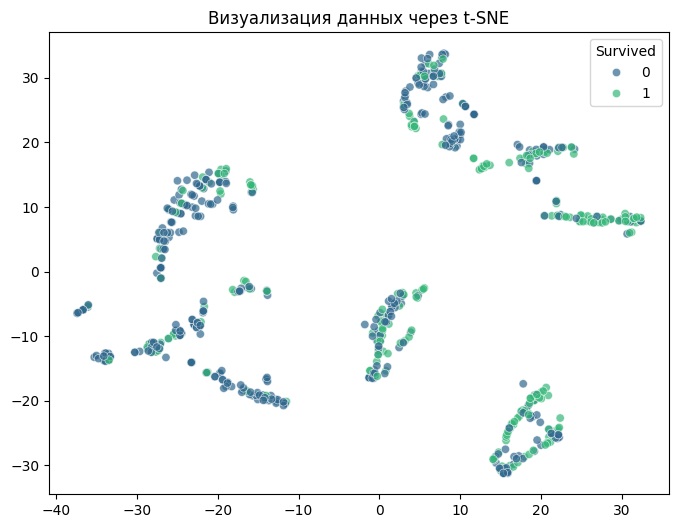

In [88]:
from sklearn.manifold import TSNE

# На трейне запускаем fit_transform. Валидацию сюда совать нельзя — t-SNE не умеет делать transform()!
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
train_tsne = tsne.fit_transform(X_train_vif_clean[current_num_features])

# Строим красивый график, раскрасив точки по реальному таргету (например, y_train)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=train_tsne[:, 0], y=train_tsne[:, 1], hue=y_train, palette='viridis', alpha=0.7)
plt.title('Визуализация данных через t-SNE')
plt.show()

**Третий тип.** Третим типом рассмотрим UMAP (Uniform Manifold Approximation and Projection). Данный алгоритм строит нечеткие сложные геометрические графы связей в многомерном пространстве и отображает их на низкоразмерное пространство.

Работает как t-SNE, но в разы быстрее и гограздо луже сохраняет не только локальную структуру (близких соседей), но и глобальную (расстояние между самими кластерами). В откличие от t-SNE у UMAP есть рабочий метод .transform(), поэтому его компоненты можно использовать как реальные признаки для обучения моделей.

In [95]:
#!pip install umap-learn

import umap

X_train_umap = X_train_vif_clean.copy()
X_val_umap = X_val_vif_clean.copy()

umap_model = umap.UMAP(n_components=2, random_state=1)
train_umap = umap_model.fit_transform(X_train_umap[current_num_features])
val_umap = umap_model.transform(X_val_umap[current_num_features])

X_train_umap['UMAP_1'] = train_umap[:, 0]
X_train_umap['UMAP_2'] = train_umap[:, 1]
X_val_umap['UMAP_1'] = val_umap[:, 0]
X_val_umap['UMAP_2'] = val_umap[:, 1]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


**Четвертый тип.** LDA (Lineral Discriminant Analysis). В отличии от PCA, который ищет просто максимальны разброс, LDA смотрит на целевые переменные y_train. Он находит такие оси, на которых проекции разных классов максимально удалены друго от друга, а разброс внутри каждого класса минимален.

Такой алгоритм идеально подготавливает признаки для классификаторов.

Однако максимальное количество компонент, которые может выдать LDA, строго ограничено формулой K-1, где K - количество классов в таргете. Для бинарной классификации LDA вернет ровно одну компоненту

In [94]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X_train_lda = X_train_vif_clean.copy()
X_val_lda = X_val_vif_clean.copy()

# LDA требует на вход y_train, так как это метод с учителем!
lda = LinearDiscriminantAnalysis(n_components=1) 
train_lda = lda.fit_transform(X_train_lda[current_num_features], y_train)
val_lda = lda.transform(X_val_lda[current_num_features])

X_train_lda['LDA_feature'] = train_lda[:, 0]
X_val_lda['LDA_feature'] = val_lda[:, 0]

С изменением числа признаков мы разобрались. Если в шаге 5 мы убирали признаки, которые дублируют друг друга, то теперь настало время убирать признаки, которые бесполезны для предскаания таргета (Y).

**Шаг седьмой.** Отбор признаков. Рассмтрим несколько групп признаков:


**Первая группа.** Статистические фильтры (Filter Methods). Эти методы оценивают каждый признак незаисимо от модели машинного обучения. Они смотрят на чистую статистику связи между конкретной колонкой и таргетом. 

**1. f_classif (ANOVA F-valude).** Алгоритм проверяет гипотезу о равенстве средних значений непрерывного признака в группах, разделенных по классам таргета. Рассчитывает отношение мегрупповой дисперсии к внутригрупповой. Чем выше F-score, тем сильнее признак разделяет целевые классы. 

Плюс заключается в том, что работает мгновенно, идеально подходит как самый первый грубый фильтр для гигантских датасетов.

Но оценивает только линейную связь, полностью игнорируя нелинейне паттерны и парные взаимодействия признаков

In [97]:
from sklearn.feature_selection import SelectKBest, f_classif

X_train_anova = X_train_vif_clean.copy()
X_val_anova = X_val_vif_clean.copy()
current_num_features = [col for col in X_train_anova.select_dtypes(include='number').columns ]#if not col.endswith('_isnan')]

# Отбираем 5 лучших фичей по тесту ANOVA
anova_selector = SelectKBest(score_func=f_classif, k=min(5, len(current_num_features)))
X_train_anova_arr = anova_selector.fit_transform(X_train_anova[current_num_features], y_train)
X_val_anova_arr = anova_selector.transform(X_val_anova[current_num_features])

anova_features = anova_selector.get_feature_names_out(current_num_features)
print(f"ANOVA оставил признаки: {list(anova_features)}")

ANOVA оставил признаки: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [3] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


**2. mutual_info_classif (Взаимная информация).** Нелинейный метод, основанный на энтропии Кульбака-Лейблера и оценке расстояний до k-ближайших соседей. Измеряет количество информации, которое можно получить о таргете, зная значение признака.

Самое главное преимущество - это способность отловить абсоллютно любые нелинейные, волновые, круговые и хаотические зависимости.

За функционал прийдется заплатить временем. Метод требует вычисления расстояний, поэтому работает ощутимо медленее, чем ANOVA. Причем на маленьких выборках склонен переобучаться под случайный шум.

In [98]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

X_train_mi = X_train_vif_clean.copy()
X_val_mi = X_val_vif_clean.copy()

# k=5 фичей по критерию взаимной информации
mi_selector = SelectKBest(score_func=mutual_info_classif, k=min(5, len(current_num_features)))
X_train_mi_arr = mi_selector.fit_transform(X_train_mi[current_num_features], y_train)
X_val_mi_arr = mi_selector.transform(X_val_mi[current_num_features])

mi_features = mi_selector.get_feature_names_out(current_num_features)
print(f"Mutual Info оставил признаки: {list(mi_features)}")

Mutual Info оставил признаки: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


**3. chi2 (Хи-квадрат).** Это статистический тест независимости признаков. Проверяет, есть ли значимые отклонения между наблюдаемыми и теоритическими (случайными) частотами совместного распределения признака и классов таргета.

Это отличный математический интсрумент для разреженных матриц и закодированных текстов.

Но математически неприменим к отрцательным числам. Если был применен на шаге 4 метод StandardScaler, то chi2 просто упает с ошибкой, так как стандартизация создает отрицательные значения.

In [99]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

X_train_chi = X_train_vif_clean.copy()
X_val_chi = X_val_vif_clean.copy()

# Важно: chi2 требует неотрицательные значения. Временно вернем их в диапазон [0, 1] через MinMaxScaler
scaler_tmp = MinMaxScaler()
X_tr_non_neg = scaler_tmp.fit_transform(X_train_chi[current_num_features])
X_val_non_neg = scaler_tmp.transform(X_val_chi[current_num_features])

chi_selector = SelectKBest(score_func=chi2, k=min(5, len(current_num_features)))
X_train_chi_arr = chi_selector.fit_transform(X_tr_non_neg, y_train)

chi_features = chi_selector.get_feature_names_out(current_num_features)
print(f"Chi2 оставил признаки: {list(chi_features)}")

Chi2 оставил признаки: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


**Вторая группа.** Методы-обертки (Wrapper Methods). Эти методы используют реальную модель (например, логистическую регрессию) как черный ящик. Они перебирают разные подмножества признаков, обучают модель и смотрят, на каком наборе метрика качества (например, ROC_AUC) будет максимальной.

**4. Рекурсивное удаление признаков (RFE).** Жадный алгоритм сверху-вниз. Модель обучается на полном наборе. По значениям весоф находится наименее важный признак и физически вырезается из таблицы. Процесс циклически повторяется, пока не останется требуемое число фичей.

Этот метод учитывает особенности конкретной модели, выкидывает признаки, которые становятся бесполезными именно в присутсвии других столбцов.

Но требует многкратного переобучения тяжелых моделей на каждом шаге. Если признаков очень много, будет выполняться часами.

In [100]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

X_train_rfe = X_train_vif_clean.copy()
X_val_rfe = X_val_vif_clean.copy()

base_lr = LogisticRegression(max_iter=1000, random_state=1)
rfe_selector = RFE(estimator=base_lr, n_features_to_select=min(4, len(current_num_features)))

rfe_selector.fit(X_train_rfe[current_num_features], y_train)
rfe_features = [col for col, keep in zip(current_num_features, rfe_selector.support_) if keep]
print(f"RFE оставил признаки: {rfe_features}")

RFE оставил признаки: ['Pclass', 'Age', 'SibSp', 'Fare']


**5. Жадный пошаговый отбор (SequentialFeatureSelector).** Алгоритм строит процесс перебора через кросс-валидацию. Режим direction='forward' стартует с пустой таблицы, перебирает признаки по одной, считает ошибку и ифксирует ту, которая дала максимальны прирост метрики. Процесс идет снизу-вверх.

Алгоритм находит математически оптимальные комбинации и синергию между признаками, не привязываясь к внутренним коэффицентам модели. 

Но это самый медленный алгоритм из всех существуюзих в ML.

In [101]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

X_train_sfs = X_train_vif_clean.copy()
X_val_sfs = X_val_vif_clean.copy()

base_lr2 = LogisticRegression(max_iter=1000, random_state=42)
sfs_selector = SequentialFeatureSelector(base_lr2, n_features_to_select=min(3, len(current_num_features)), 
                                         direction='forward', cv=3, n_jobs=-1)

sfs_selector.fit(X_train_sfs[current_num_features], y_train)
sfs_features = sfs_selector.get_feature_names_out(current_num_features)
print(f"SFS Forward оставил признаки: {list(sfs_features)}")

SFS Forward оставил признаки: ['Pclass', 'Age', 'Fare']


**Третья группа.** Встроенные методы (Emvedded Methods). Эти методы отбирают автоматически внутри самой модели в процессе ее обучения. Нам не нужно запускать сторонние модели.

**1. L1-регуляризация (Lasso).** Алгоритм добавляет к стандартной функции потерь штраф за сумму абсолютных значений весов ($L1 = \alpha \sum |w_i|$). Из-за геометрии ромбовидных ограничений L1-штрафа оптимизатор принудительно зануляет веса наименее полезных колонок, превращая их коэффициенты строго в 0.

Благодаря этому отрабатывает за один проход обучения модели, идеально подходит для отбора признаков перед запуском финальных линейных моделей.

Но накладывает сильное линейное ограничение. Если между признаком и таргетом сложная нелинейная связь, Lasso занулит этот признак, посчитав его бесполезным.

In [102]:
from sklearn.linear_model import LogisticRegression

X_train_l1 = X_train_vif_clean.copy()

# penalty='l1' и solver='liblinear' активируют Lasso
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.2, random_state=1)
lasso_model.fit(X_train_l1[current_num_features], y_train)

# Вытаскиваем коэффициенты и смотрим, кто не равен нулю
lasso_coefs = pd.Series(lasso_model.coef_[0], index=current_num_features)
lasso_selected_features = lasso_coefs[lasso_coefs != 0].index.tolist()

print(f"L1-регуляризация оставила признаки (вес не 0): {lasso_selected_features}")

L1-регуляризация оставила признаки (вес не 0): ['Pclass', 'Age', 'SibSp', 'Fare']


**2. Важность признаков в деревьях решений (feature_importances_).** Если L1-регуляризация предназначалась для линейных моделей, feature_imortances предназначен для деревьев и бустингов. Алгоритм обучает ансамбль, считает метрику MDI (Mean Decrease in Impurity) - насколько сильно расщепление по данному признаку снижает неопределенность/энтропию во всех узлах всех деревьев. Признаки с важностью ниже выбранного порога отбрасываются.

Не зависит от линейности данных, отлично ловит сложные нелинейные структуры и пороговые зависимости.

Но встроенный подсчет MDI в sklearn имеет серьезное математическое смещение - он искуственно завышае важность непрерывных признаков с большим количеством уникальных значений (высокой кардинальностью). 

In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

X_train_rf = X_train_vif_clean.copy()
X_val_rf = X_val_vif_clean.copy()

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# SelectFromModel автоматически отберет признаки со скором выше среднего (threshold='mean')
embed_rf_selector = SelectFromModel(estimator=rf, threshold='mean')
X_train_rf_arr = embed_rf_selector.fit_transform(X_train_rf[current_num_features], y_train)
X_val_rf_arr = embed_rf_selector.transform(X_val_rf[current_num_features])

rf_features = embed_rf_selector.get_feature_names_out(current_num_features)
print(f"Random Forest оставил признаки: {list(rf_features)}")

Random Forest оставил признаки: ['Age', 'Fare']


Возникает закономерный вопрос, а почему на шаге 7 мы использовали датасет из шага 5? Ответ на него очень прост: мы либо используем Шаг 6, либо исопльзуем Шаг 7. 

Шаг 6 используется, если
1. Признаков слишком много: больше 100 признаков.
2. Необходима визуализировать, показать распределение данных на плоскости (t-SNE, UMAP или PCA).
3. Признаки - это шум. Иногда исходные данные - это грязные измерения, которые по отдельности несут мало смысла, но их комбинация содержит четкий сигнал (PCA).

Шаг 7 же используется, если
1. Умеренное количество признаков: всего 20-50 признаков.
2. Критически важна интерпретируемость, где признаки должны что-то физически обозначать, а не столбец "компонента 3".
3. Используются линейные модели или деревья. Линейным моделям гораздо проще учиться на отобранных родных признаках.

In [25]:
def check_submission(my_prediction, submission):
    target_col = my_prediction.columns[1]  # Автоматически берем колонку с предсказанием
    mismatch_rate = (my_prediction[target_col] != submission[target_col]).mean() * 100
    print(f"Модель изменила {mismatch_rate:.2f}% ответов по сравнению с шаблоном.")